In [37]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

In [38]:
# Загрузка необходимых NLTK-ресурсов
nltk.download('punkt')
nltk.download('punkt-tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Инициализация лемматизатора и стоп-слов
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package punkt to /Users/zeto/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading punkt-tab: Package 'punkt-tab' not found in
[nltk_data]     index
[nltk_data] Downloading package stopwords to /Users/zeto/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/zeto/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 1. Предобработка данных с использованием pymorphy3

In [39]:
df = pd.read_csv('restaurant_reviews.csv')
df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [40]:
# Проверка пропущенных значений
print(f"Количество пропущенных значений в 'Review': {df['Review'].isnull().sum()}")

# Заполнение пропусков пустыми строками
df['Review'] = df['Review'].fillna('')

# Проверка типов данных
print(df['Review'].apply(type).value_counts())

Количество пропущенных значений в 'Review': 45
Review
<class 'str'>    10000
Name: count, dtype: int64


Предобработка текста

In [41]:
def preprocess_text(text):
    if not isinstance(text, str):
        return []
    # Удаление символов пунктуации и чисел
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    # Приведение к нижнему регистру
    text = text.lower()
    
    # Токенизация
    words = word_tokenize(text)
    
    # Удаление стоп-слов и лемматизация
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return lemmatized_words

Применение предобработки к столбцу с отзывами

In [42]:
# Заполнение пропущенных значений пустыми строками
df['Review'] = df['Review'].fillna('')

# Применение предобработки
df['processed_review'] = df['Review'].apply(preprocess_text)

# Просмотр результатов
print(df[['Review', 'processed_review']].head())

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   
3  Soumen das and Arun was a great guy. Only beca...   
4  Food is good.we ordered Kodi drumsticks and ba...   

                                    processed_review  
0  [ambience, good, food, quite, good, saturday, ...  
1  [ambience, good, pleasant, evening, service, p...  
2  [must, try, great, food, great, ambience, thnx...  
3  [soumen, da, arun, great, guy, behavior, since...  
4  [food, goodwe, ordered, kodi, drumstick, baske...  


Преобразование текстов в список предложений

In [43]:
sentences = df['processed_review'].tolist()

# 2. Построение модели Word2Vec с использованием gensim

In [44]:
from gensim.models import Word2Vec

In [45]:
word2vec = Word2Vec(
    sentences=sentences,      # Список токенизированных предложений
    vector_size=100,          # Размерность векторов
    window=5,                 # Окно контекста
    min_count=5,              # Минимальная частота слова
    sg=0,                     # Архитектура модели (0 - CBOW, 1 - Skip-gram)
    workers=4,                # Количество потоков для обучения
    epochs=10                 # Количество эпох
)

word2vec.train(sentences, total_examples=word2vec.corpus_count, epochs=word2vec.epochs)

(2190207, 2729230)

1. **CBOW (Continuous Bag of Words)**:
    - **Описание**: Модель предсказывает целевое слово на основе контекста (окружающих слов).
    - **Особенности**: Быстрее обучается, лучше работает на больших корпусах.
    - **Параметр**: `sg=0`
2. **Skip-gram**:
    - **Описание**: Модель предсказывает контекстные слова на основе целевого слова.
    - **Особенности**: Лучше справляется с редкими словами, обычно более точная, но требует больше вычислительных ресурсов.
    - **Параметр**: `sg=1`

In [46]:
# Получение списка всех слов в словаре
vocab = list(word2vec.wv.key_to_index.keys())

# Выбор слова из словаря
selected_word = vocab[0]  # Можно выбрать любое другое слово

similar_words = word2vec.wv.most_similar(selected_word, topn=10)
print(f"Слова, похожие на '{selected_word}':")
for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Слова, похожие на 'good':
nice: 0.7327
great: 0.7060
decent: 0.6188
superb: 0.6111
awesome: 0.5971
satisfactory: 0.5643
liked: 0.5537
okay: 0.5456
average: 0.5417
excellent: 0.5414


In [47]:
word = 'food'

if word in word2vec.wv:
    similar_words = word2vec.wv.most_similar(word, topn=10)
    print(f"Слова, похожие на '{word}':")
    for similar_word, similarity in similar_words:
        print(f"{similar_word}: {similarity:.4f}")
else:
    print(f"Слово '{word}' отсутствует в словаре.")
    sample_word = list(word2vec.wv.key_to_index.keys())[0]
    similar_words = word2vec.wv.most_similar(sample_word, topn=10)
    print(f"Слова, похожие на '{sample_word}':")
    for similar_word, similarity in similar_words:
        print(f"{similar_word}: {similarity:.4f}")

Слова, похожие на 'food':
foodit: 0.4250
v: 0.4183
foodi: 0.4063
restaurant: 0.3812
hygiene: 0.3581
atmosphere: 0.3543
foodthe: 0.3520
reasonably: 0.3497
self: 0.3462
tooooo: 0.3438


# 3. Построение и сравнение моделей с различными параметрами

Шаг 1: Определение различных наборов параметров

In [49]:
param_sets = [
    {'vector_size': 50, 'window': 5, 'min_count': 2, 'sg': 0},
    {'vector_size': 100, 'window': 5, 'min_count': 2, 'sg': 1},
    {'vector_size': 100, 'window': 10, 'min_count': 5, 'sg': 0},
]

- **vector_size**: Размерность векторного пространства, в котором будут представлены слова.
- **window**: Максимальное расстояние между текущим словом и словами-контекстами.
- **min_count**: Минимальная частота слова для включения его в словарь.
- **sg**: Архитектура модели (`0` для CBOW, `1` для Skip-gram).

Шаг 2: Обучение моделей и сохранение результатов

In [50]:
models = []
for idx, params in enumerate(param_sets):
    model = Word2Vec(
        sentences=sentences,
        vector_size=params['vector_size'],
        window=params['window'],
        min_count=params['min_count'],
        sg=params['sg'],
        workers=4,
        epochs=10
    )
    model.train(sentences, total_examples=model.corpus_count, epochs=model.epochs)
    models.append(model)
    print(f"Модель {idx+1} обучена с параметрами: {params}")

Модель 1 обучена с параметрами: {'vector_size': 50, 'window': 5, 'min_count': 2, 'sg': 0}
Модель 2 обучена с параметрами: {'vector_size': 100, 'window': 5, 'min_count': 2, 'sg': 1}
Модель 3 обучена с параметрами: {'vector_size': 100, 'window': 10, 'min_count': 5, 'sg': 0}


Шаг 3: Сравнение моделей

In [134]:
words_to_compare = ['food', 'service', 'ambience']
for word in words_to_compare:
    print(f"\nСлова, похожие на '{word}':")
    for idx, model in enumerate(models):
        if word in model.wv:
            similar = model.wv.most_similar(word, topn=5)
            print(f"Модель {idx+1}: {similar}")
        else:
            print(f"Модель {idx+1}: Слово '{word}' отсутствует в словаре.")


Слова, похожие на 'food':
Модель 1: [('availble', 0.47623294591903687), ('timely', 0.4677797257900238), ('foodi', 0.4540967643260956), ('guaranteed', 0.4485110342502594), ('foodgood', 0.44709938764572144)]
Модель 2: [('foodgood', 0.7111569046974182), ('continuous', 0.7068603038787842), ('greatest', 0.7025550603866577), ('deliverytasty', 0.699211835861206), ('ambiencegreat', 0.6972173452377319)]
Модель 3: [('cleanliness', 0.3751419484615326), ('foodthe', 0.372004896402359), ('thalis', 0.3627539873123169), ('seems', 0.35987424850463867), ('hospitable', 0.35644710063934326)]

Слова, похожие на 'service':
Модель 1: [('tushar', 0.6558487415313721), ('hospitality', 0.6557486057281494), ('servicing', 0.6395018696784973), ('serving', 0.5772823691368103), ('behavior', 0.570961594581604)]
Модель 2: [('sevice', 0.7802334427833557), ('ty', 0.7554851174354553), ('deliverytasty', 0.7480577230453491), ('tushar', 0.7269507646560669), ('preffered', 0.6994361281394958)]
Модель 3: [('polite', 0.55296880

# 4. Визуализация результатов с использованием t-SNE

Шаг 1: Установка и импорт необходимых библиотек

In [56]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Шаг 2: Выбор слов и получение их векторов

In [53]:
selected_words = ['food', 'service', 'ambience']  # Выберите свои слова
similar_words_dict = {}

for word in selected_words:
    if word in word2vec.wv:
        similar = word2vec.wv.most_similar(word, topn=10)
        similar_words_dict[word] = [word] + [w for w, _ in similar]
    else:
        print(f"Слово '{word}' отсутствует в словаре.")

Шаг 3: Подготовка данных для визуализации

In [54]:
all_words = set()
for words in similar_words_dict.values():
    all_words.update(words)

word_vectors = [word2vec.wv[word] for word in all_words]
word_list = list(all_words)

In [60]:
word_vectors = np.array(word_vectors)

print(f"Форма word_vectors: {word_vectors.shape}")

Форма word_vectors: (32, 100)


Шаг 4: Применение t-SNE для уменьшения размерности

In [61]:
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
embeddings = tsne.fit_transform(word_vectors)

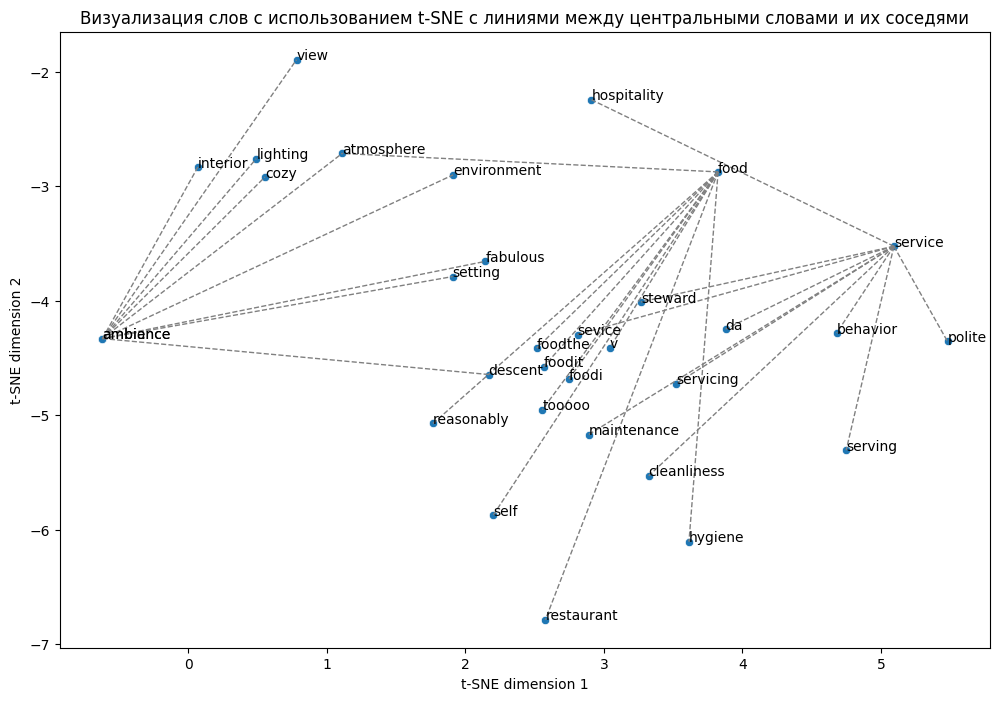

In [116]:
word_to_index = {word: i for i, word in enumerate(word_list)}

plt.figure(figsize=(12, 8))
sns.scatterplot(x=embeddings[:,0], y=embeddings[:,1])

for i, word in enumerate(word_list):
    plt.annotate(word, (embeddings[i,0], embeddings[i,1]))

for word, similar_words in similar_words_dict.items():
    center_index = word_to_index[word]
    for similar_word in similar_words[1:]: 
        similar_index = word_to_index[similar_word]
        plt.plot([embeddings[center_index, 0], embeddings[similar_index, 0]],
                 [embeddings[center_index, 1], embeddings[similar_index, 1]],
                 color='gray', linestyle='--', linewidth=1)

plt.title('Визуализация слов с использованием t-SNE с линиями между центральными словами и их соседями')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.show()

Какие задачи можно решить с помощью модели Word2vec?
- **Нахождение синонимов**: Поиск слов с похожим значением.
- **Классификация текстов**: Представление текстов в виде векторов для дальнейшей классификации.
- **Анализ настроений**: Определение эмоциональной окраски текста.
- **Рекомендательные системы**: Предложение схожих товаров или контента.
- **Поиск и извлечение информации**: Улучшение качества поиска за счет семантического понимания запросов.

Какие еще есть модели векторных представлений слов и в чем их преимущества?
- **GloVe (Global Vectors for Word Representation)**:
    - **Преимущества**: Использует глобальную статистику корпуса, хорошо захватывает линейные отношения между словами.
- **FastText**:
    - **Преимущества**: Учитывает подслова (n-граммы), что позволяет лучше обрабатывать редкие и неизвестные слова.
- **ELMo (Embeddings from Language Models)**:
    - **Преимущества**: Контекстуальные эмбеддинги, зависят от предложения, улучшая понимание смысла слова в конкретном контексте.
- **BERT (Bidirectional Encoder Representations from Transformers)**:
    - **Преимущества**: Глубокие контекстуальные представления, подходит для многих задач NLP, включая вопросно-ответные системы и анализ тональности.

# 6. Преобразование текстов в векторное представление

Шаг 1: Получение векторов слов для каждого текста

In [117]:
import numpy as np

def get_average_vector(text, model):
    vectors = [model.wv[word] for word in text if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

Шаг 2: Применение функции ко всем текстам

In [118]:
model_names = [f'model_{i+1}' for i in range(len(models))]

for name, model in zip(model_names, models):
    df[f'text_vector_{name}'] = df['processed_review'].apply(lambda x: get_average_vector(x, model))
    print(f"Векторы для {name} добавлены в DataFrame.")

Векторы для model_1 добавлены в DataFrame.
Векторы для model_2 добавлены в DataFrame.
Векторы для model_3 добавлены в DataFrame.


Шаг 3: Различные векторные представления

In [119]:
print(df[[f'text_vector_{name}' for name in model_names]].head())

                                 text_vector_model_1  \
0  [0.19325562, -0.36990327, 0.6471287, -0.158848...   
1  [0.9743112, -0.4213581, 0.5165182, -0.4987419,...   
2  [0.29898494, 0.13388854, 0.35650325, -0.627260...   
3  [0.28037834, -0.11877095, 0.7528056, 0.1359749...   
4  [0.1559838, -0.62587863, 0.60038215, 0.4124372...   

                                 text_vector_model_2  \
0  [-0.16823038, 0.24370372, 0.07931305, 0.001546...   
1  [-0.29552338, 0.29804078, 0.12072076, 0.083147...   
2  [-0.07224341, 0.24707893, -0.07870849, 0.15012...   
3  [-0.15767884, 0.30308408, 0.1816093, 0.0288721...   
4  [-0.009705216, 0.13487716, 0.1349546, 0.033508...   

                                 text_vector_model_3  
0  [0.122200094, 0.14339866, -0.20481911, 0.48189...  
1  [-0.22407958, 0.11263967, -0.19420688, 0.65483...  
2  [0.47284782, 0.14726841, -0.26985744, 0.637969...  
3  [0.27076286, 0.16096847, -0.17560649, 0.439693...  
4  [0.72393787, -0.53964144, 0.24764706, 0.017600..

# 7. Обучение моделей классификации

Шаг 1: Подготовка данных

In [132]:
from sklearn.model_selection import train_test_split

y = df['Rating'].values

y = pd.to_numeric(y, errors='coerce')

num_nan_y = np.isnan(y).sum()
print(f"Количество NaN в целевом признаке 'Rating': {num_nan_y}")

if num_nan_y > 0:
    print("Обнаружены NaN в целевом признаке. Удаляем строки с NaN.")
    mask = ~np.isnan(y)
    df_clean = df[mask].reset_index(drop=True)
    y = df_clean['Rating'].values
else:
    df_clean = df.copy()

X_dict = {}

for name in model_names:
    X = np.vstack(df_clean[f'text_vector_{name}'].values)
    X_dict[name] = X
    print(f"Признаки для {name} подготовлены. Shape: {X.shape}")

Количество NaN в целевом признаке 'Rating': 39
Обнаружены NaN в целевом признаке. Удаляем строки с NaN.
Признаки для model_1 подготовлены. Shape: (9961, 50)
Признаки для model_2 подготовлены. Shape: (9961, 100)
Признаки для model_3 подготовлены. Shape: (9961, 100)


Шаг 2: Обучение и оценка моделей классификации

In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier()
}

results = {}

for model_name, clf in classification_models.items():
    print(f"\nОбучение модели: {model_name}")
    results[model_name] = {}
    
    for vec_name, X in X_dict.items():
        print(f"  Используется векторная модель: {vec_name}")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        clf.fit(X_train, y_train)
        
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, zero_division=0)
        results[model_name][vec_name] = {
            'accuracy': accuracy,
            'report': report
        }
        
        print(f"    Accuracy: {accuracy:.4f}")
        print(f"    Classification Report:\n{report}")


Обучение модели: Logistic Regression
  Используется векторная модель: model_1
    Accuracy: 0.6131
    Classification Report:
              precision    recall  f1-score   support

           1       0.64      0.85      0.73       338
         1.5       0.00      0.00      0.00         2
           2       0.22      0.04      0.06       142
         2.5       0.00      0.00      0.00         7
           3       0.33      0.21      0.26       228
         3.5       0.00      0.00      0.00         5
           4       0.48      0.54      0.51       476
         4.5       0.00      0.00      0.00         9
           5       0.74      0.79      0.77       786

    accuracy                           0.61      1993
   macro avg       0.27      0.27      0.26      1993
weighted avg       0.57      0.61      0.58      1993

  Используется векторная модель: model_2
    Accuracy: 0.6237
    Classification Report:
              precision    recall  f1-score   support

           1       0.67 

In [136]:
best_model_name = None
best_vec_name = None
best_accuracy = 0

for model_name, vec_results in results.items():
    for vec_name, metrics in vec_results.items():
        if metrics['accuracy'] > best_accuracy:
            best_accuracy = metrics['accuracy']
            best_model_name = model_name
            best_vec_name = vec_name

print("\nЛучшая модель:")
print(f"Классификатор: {best_model_name}")
print(f"Векторная модель: {best_vec_name}")
print(f"Точность: {best_accuracy:.4f}")
print(f"Отчёт по классификации:\n{results[best_model_name][best_vec_name]['report']}")


Лучшая модель:
Классификатор: SVM
Векторная модель: model_2
Точность: 0.6372
Отчёт по классификации:
              precision    recall  f1-score   support

           1       0.67      0.88      0.76       338
         1.5       0.00      0.00      0.00         2
           2       0.29      0.04      0.07       142
         2.5       0.00      0.00      0.00         7
           3       0.39      0.24      0.29       228
         3.5       0.00      0.00      0.00         5
           4       0.50      0.62      0.55       476
         4.5       0.00      0.00      0.00         9
           5       0.78      0.78      0.78       786

    accuracy                           0.64      1993
   macro avg       0.29      0.29      0.27      1993
weighted avg       0.60      0.64      0.61      1993

